# Point-in-Time Leakage Experiment

Notebook này trình bày trực tiếp toàn bộ model research flow: feature exploration, temporal split, Dummy baseline, ba LightGBM experiment, metric comparison và evaluation visualization. SQL/PIT dataset preparation được tái sử dụng từ package; model initialization, `fit`, `predict_proba` và metrics không bị giấu sau một wrapper đơn khối.

## 1. Experiment Objective

PIT-correct features chỉ dùng event trong **`[cutoff - window, cutoff)`**: bao gồm biên dưới, loại event tại cutoff và mọi event tương lai. Future-looking features cố ý dùng **`(cutoff, cutoff + window]`** để mô phỏng leakage. Mục tiêu không phải chứng minh future-only luôn có metric cao hơn; mục tiêu là đo rủi ro khi thông tin chưa tồn tại tại prediction time lọt vào model. Controlled comparison chính là PIT so với PIT + future.

In [1]:
from pathlib import Path
import sys

import duckdb
from lightgbm import LGBMClassifier
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if not (project_root / 'src' / 'pit_feature_store').exists():
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from pit_feature_store.leakage import (
    prepare_experiment_frames,
    temporal_masks,
)

database_path = project_root / 'artifacts' / 'warehouse.duckdb'
catalog_path = project_root / 'config' / 'feature_catalog.yaml'
report_dir = project_root / 'artifacts' / 'reports'
metrics_path = report_dir / 'leakage_metrics.csv'
markdown_path = report_dir / 'leakage_experiment.md'
random_state = 42
train_fraction = 0.8

if not database_path.exists():
    raise FileNotFoundError(
        'Chưa có warehouse. Hãy chạy scripts/init_warehouse.py và offline engine trước.'
    )
plt.style.use('seaborn-v0_8-whitegrid')
database_path

WindowsPath('C:/Users/tiennd49/Documents/point-in-time-feature-store/artifacts/warehouse.duckdb')

### Reusable data preparation

Cell này chỉ gọi reusable data/PIT logic: tạo future dataset, lọc cohort đủ observation window, chọn split timestamp và load ba DataFrame có cùng label spine. Không train model trong module call này.

In [2]:
connection = duckdb.connect(database_path.as_posix())
try:
    prepared = prepare_experiment_frames(
        connection, catalog_path, train_fraction=train_fraction
    )
finally:
    connection.close()

catalog = prepared['catalog']
bounds = prepared['bounds']
split_ts = prepared['split_ts']
pit_columns = prepared['pit_columns']
future_columns = prepared['future_columns']
augmented_columns = prepared['augmented_columns']
frames = prepared['frames']

{name: frame.shape for name, frame in frames.items()}

{'pit': (370770, 8),
 'future_only': (370770, 8),
 'pit_plus_future': (370770, 12)}

## 2. Features Used

`future_only` giữ tên bốn PIT feature để đáp ứng schema experiment; bảng dưới làm rõ semantic mapping trong controlled PIT + future dataset.

In [3]:
feature_table = pd.DataFrame(
    {
        'pit_feature': [feature.name for feature in catalog.features],
        'description': [feature.description for feature in catalog.features],
        'aggregation': [feature.aggregation for feature in catalog.features],
        'window_hours': [feature.window_hours for feature in catalog.features],
        'future_feature': future_columns,
    }
)
display(feature_table)

,pit_feature,description,aggregation,window_hours,future_feature
0,sum_amt_24h,Tổng giá trị giao dịch của uid trong 24 giờ tr...,sum,24,future_sum_amt_24h
1,count_txn_24h,Số giao dịch của uid trong 24 giờ trước cutoff.,count,24,future_count_txn_24h
2,sum_amt_7d,Tổng giá trị giao dịch của uid trong 7 ngày tr...,sum,168,future_sum_amt_7d
3,time_since_last_txn_sec,Số giây từ giao dịch gần nhất của uid trong 72...,time_since_last,720,time_to_next_txn_sec


## 3. Feature Exploration

Mỗi feature được clip tại p99 chỉ cho visualization. `log1p` được dùng cho các feature liên tục/skew; DataFrame dùng để train không bị chỉnh sửa. Fraud và non-fraud được overlay để nhìn distribution trước khi fit model.

,count,mean,std,min,25%,50%,75%,95%,99%,max,missing_pct
sum_amt_24h,370770.0,412.399998,1053.707091,0.0,0.0,0.00,312.4500,2254.84,5.226188e+03,69654.232,0.000000
count_txn_24h,370770.0,2.981101,6.375025,0.0,0.0,0.00,3.0000,16.00,3.300000e+01,87.000,0.000000
sum_amt_7d,370770.0,2570.386540,5796.061155,0.0,0.0,329.95,2176.3675,13889.71,3.229534e+04,69654.232,0.000000
time_since_last_txn_sec,296618.0,246787.620515,461803.213722,1.0,4459.0,48768.50,245567.2500,1308323.00,2.255780e+06,2591903.000,19.999461


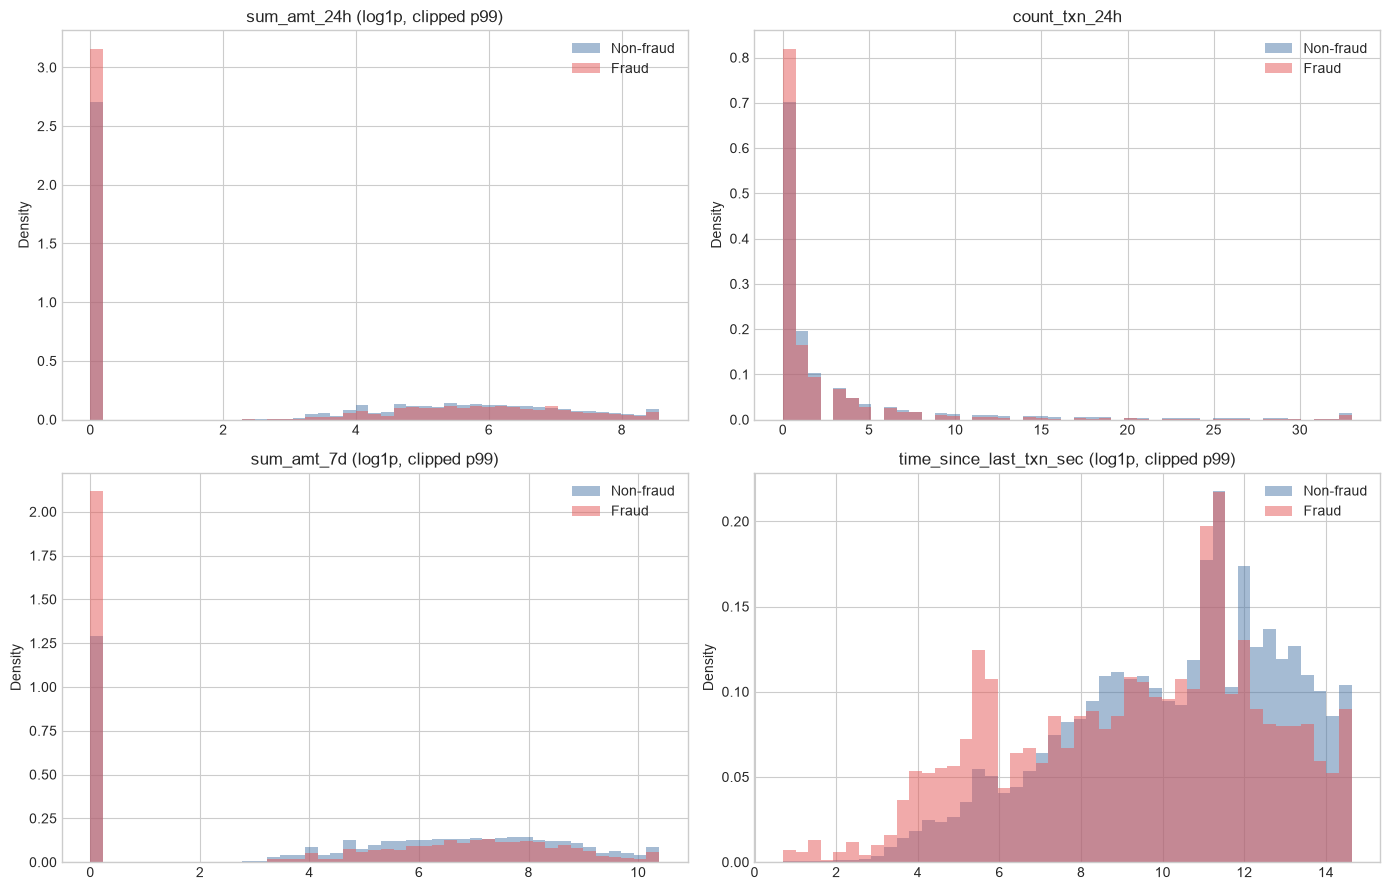

In [4]:
pit_frame = frames['pit']
plot_frame = pit_frame.sample(
    n=min(100_000, len(pit_frame)),
    random_state=random_state,
)
feature_summary = pit_frame[pit_columns].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).T
feature_summary['missing_pct'] = 100.0 * pit_frame[pit_columns].isna().mean()
display(feature_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, pit_columns, strict=True):
    upper = pit_frame[feature].quantile(0.99)
    for label, color, name in [(0, '#4C78A8', 'Non-fraud'), (1, '#E45756', 'Fraud')]:
        values = plot_frame.loc[plot_frame['label'] == label, feature].dropna()
        values = values.clip(upper=upper)
        if feature != 'count_txn_24h':
            values = np.log1p(values.clip(lower=0))
        ax.hist(values, bins=45, density=True, alpha=0.5, color=color, label=name)
    suffix = '' if feature == 'count_txn_24h' else ' (log1p, clipped p99)'
    ax.set_title(feature + suffix)
    ax.set_ylabel('Density')
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Temporal Split

Cohort chỉ giữ cutoff có đủ 720 giờ quan sát ở cả hai phía. Train dùng `cutoff_ts < split_ts`; test dùng `cutoff_ts >= split_ts`, nên các giao dịch cùng timestamp không bị chia sang hai tập. Không dùng random split vì production prediction diễn ra về phía tương lai.

In [5]:
train_mask, test_mask = temporal_masks(pit_frame, split_ts)
train_labels = pit_frame.loc[train_mask, 'label'].astype(int)
test_labels = pit_frame.loc[test_mask, 'label'].astype(int)

cohort_summary = pd.DataFrame(
    [{
        'eligible_start': bounds.start,
        'eligible_end': bounds.end,
        'total_rows': bounds.total_rows,
        'eligible_rows': bounds.eligible_rows,
        'excluded_rows': bounds.excluded_rows,
        'split_ts': split_ts,
    }]
)
split_summary = pd.DataFrame(
    [
        {
            'partition': 'train',
            'rows': int(train_mask.sum()),
            'fraud_count': int(train_labels.sum()),
            'fraud_rate': float(train_labels.mean()),
            'start': pit_frame.loc[train_mask, 'cutoff_ts'].min(),
            'end': pit_frame.loc[train_mask, 'cutoff_ts'].max(),
        },
        {
            'partition': 'test',
            'rows': int(test_mask.sum()),
            'fraud_count': int(test_labels.sum()),
            'fraud_rate': float(test_labels.mean()),
            'start': pit_frame.loc[test_mask, 'cutoff_ts'].min(),
            'end': pit_frame.loc[test_mask, 'cutoff_ts'].max(),
        },
    ]
)
display(cohort_summary)
display(split_summary)

,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts
0,2018-01-01,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56


,partition,rows,fraud_count,fraud_rate,start,end
0,train,296615,11741,0.039583,2018-01-01 00:00:05,2018-04-05 23:19:51
1,test,74155,2527,0.034077,2018-04-05 23:19:56,2018-05-02 23:58:49


## 5. Baseline Model

Dummy baseline dùng class prior của train set và không nhận feature nghiệp vụ. Với score hằng số, ROC-AUC xấp xỉ 0.5 và PR-AUC bằng prevalence fraud của test set.

In [6]:
metric_rows = []
prediction_frames = []

def validated_metric_arrays(labels, probabilities, context):
    label_values = np.asarray(labels, dtype=float)
    probability_values = np.asarray(probabilities, dtype=float)
    if label_values.ndim != 1 or probability_values.ndim != 1:
        raise ValueError(f'{context}: labels and probabilities must be 1-D.')
    if len(label_values) != len(probability_values):
        raise ValueError(f'{context}: labels and probabilities are misaligned.')
    if not np.isfinite(label_values).all():
        raise ValueError(f'{context}: labels contain NaN or infinity.')
    if not np.isfinite(probability_values).all():
        raise ValueError(f'{context}: probabilities contain NaN or infinity.')
    if not np.isin(label_values, [0.0, 1.0]).all():
        raise ValueError(f'{context}: labels must be binary 0/1.')
    return label_values.astype(int), probability_values

def assert_no_infinite_features(frame, columns, context):
    values = frame.loc[:, columns].to_numpy(dtype=float, na_value=np.nan)
    if np.isinf(values).any():
        raise ValueError(f'{context}: feature matrix contains infinity.')
    # NaN is an intentional missing value and is handled natively by LightGBM.

def record_evaluation(model_name, dataset_name, columns, frame, mask, probabilities):
    labels = frame.loc[mask, 'label'].astype(int) # Lấy label thật của tập test
    label_values, probability_values = validated_metric_arrays(
        labels, probabilities, model_name
    )
    if np.unique(label_values).size < 2:
        raise ValueError(f'{model_name}: evaluation requires both classes.')
    roc_auc = float(roc_auc_score(label_values, probability_values)) # ROC-AUC kiểm tra khả năng mô hình xếp giao dịch fraud cao hơn non-fraud.
    pr_auc = float(average_precision_score(label_values, probability_values)) # PR-AUC đo hiệu quả tìm fraud, đặc biệt phù hợp với dữ liệu mất cân bằng
    test_fraud_rate = float(label_values.mean())
    row = {
        'model': model_name,
        'dataset': dataset_name,
        'eligible_start': bounds.start.isoformat(sep=' '),
        'eligible_end': bounds.end.isoformat(sep=' '),
        'total_rows': bounds.total_rows,
        'eligible_rows': bounds.eligible_rows,
        'excluded_rows': bounds.excluded_rows,
        'split_ts': split_ts.isoformat(sep=' '),
        'train_rows': int(train_mask.sum()),
        'test_rows': int(mask.sum()),
        'train_positive': int(train_labels.sum()),
        'test_positive': int(labels.sum()),
        'train_fraud_rate': float(train_labels.mean()),
        'test_fraud_rate': test_fraud_rate,
        'feature_count': len(columns),
        'feature_columns': '|'.join(columns),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'pr_auc_lift': pr_auc / test_fraud_rate,
    }
    predictions = frame.loc[mask, ['label_id', 'cutoff_ts', 'label']].copy()
    predictions['dataset'] = dataset_name
    predictions['model'] = model_name
    predictions['score'] = probability_values
    metric_rows.append(row)
    prediction_frames.append(predictions)
    return row

dummy_model = DummyClassifier(strategy='prior')
dummy_model.fit(np.zeros((len(train_labels), 1)), train_labels)
dummy_probabilities = dummy_model.predict_proba(
    np.zeros((len(test_labels), 1))
)[:, 1]
dummy_result = record_evaluation(
    'Dummy baseline', 'dummy_baseline', [], pit_frame, test_mask,
    dummy_probabilities,
)
display(pd.DataFrame([dummy_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,Dummy baseline,dummy_baseline,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,0,,0.5,0.034077,1.0


## 6. PIT LightGBM

Helper nhỏ bên dưới chỉ tránh lặp code giữa ba experiment. Việc khởi tạo LightGBM, `fit`, `predict_proba` và metric call đều xuất hiện trực tiếp trong notebook. Parameters giữ nguyên experiment đã được duyệt để metric có thể so sánh.

In [7]:
def fit_lightgbm_experiment(model_name, dataset_name, frame, columns):
    current_train_mask, current_test_mask = temporal_masks(frame, split_ts)
    y_train = frame.loc[current_train_mask, 'label'].astype(int)
    X_train = frame.loc[current_train_mask, columns]
    X_test = frame.loc[current_test_mask, columns]
    assert_no_infinite_features(X_train, columns, f'{model_name} train')
    assert_no_infinite_features(X_test, columns, f'{model_name} test')

    model = LGBMClassifier(
        objective='binary',
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1,
        deterministic=True,
        force_col_wise=True,
        verbosity=-1,
    )
    model.fit(X_train, y_train)
    probabilities = model.predict_proba(X_test)[:, 1]
    result = record_evaluation(
        model_name, dataset_name, columns, frame, current_test_mask,
        probabilities,
    )
    return model, result, probabilities

pit_model, pit_result, pit_probabilities = fit_lightgbm_experiment(
    'PIT LightGBM', 'pit', frames['pit'], pit_columns
)
display(pd.DataFrame([pit_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,PIT LightGBM,pit,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.679783,0.067894,1.992364


## 7. Future-only Model

Model này thay toàn bộ historical signal bằng future-looking values trên cùng label spine và temporal split. Đây là leakage experiment theo specification, không phải model hợp lệ cho production.

In [8]:
future_model, future_result, future_probabilities = fit_lightgbm_experiment(
    'Future-only LightGBM',
    'future_only',
    frames['future_only'],
    pit_columns,
)
display(pd.DataFrame([future_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,Future-only LightGBM,future_only,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,4,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.674214,0.064931,1.905402


## 8. PIT + Future Model

Controlled comparison thêm bốn future features vào đúng bốn PIT features. So với PIT model, khác biệt chính là quyền truy cập thông tin tương lai.

In [9]:
augmented_model, augmented_result, augmented_probabilities = fit_lightgbm_experiment(
    'PIT + future LightGBM',
    'pit_plus_future',
    frames['pit_plus_future'],
    augmented_columns,
)
display(pd.DataFrame([augmented_result]))

,model,dataset,eligible_start,eligible_end,total_rows,eligible_rows,excluded_rows,split_ts,train_rows,test_rows,train_positive,test_positive,train_fraud_rate,test_fraud_rate,feature_count,feature_columns,roc_auc,pr_auc,pr_auc_lift
0,PIT + future LightGBM,pit_plus_future,2018-01-01 00:00:00,2018-05-02 23:58:51,590540,370770,219770,2018-04-05 23:19:56,296615,74155,11741,2527,0.039583,0.034077,8,sum_amt_24h|count_txn_24h|sum_amt_7d|time_sinc...,0.705485,0.074536,2.187256


## 9. Model Comparison

In [10]:
metrics = pd.DataFrame(metric_rows)
predictions = pd.concat(prediction_frames, ignore_index=True)
model_comparison = metrics[[
    'model', 'feature_count', 'roc_auc', 'pr_auc', 'pr_auc_lift'
]].copy()
display(model_comparison)

indexed = metrics.set_index('dataset')
controlled_comparison = pd.DataFrame(
    [{
        'comparison': 'PIT + future minus PIT',
        'roc_auc_delta': (
            indexed.loc['pit_plus_future', 'roc_auc']
            - indexed.loc['pit', 'roc_auc']
        ),
        'pr_auc_delta': (
            indexed.loc['pit_plus_future', 'pr_auc']
            - indexed.loc['pit', 'pr_auc']
        ),
    }]
)
display(controlled_comparison)

,model,feature_count,roc_auc,pr_auc,pr_auc_lift
0,Dummy baseline,0,0.500000,0.034077,1.000000
1,PIT LightGBM,4,0.679783,0.067894,1.992364
2,Future-only LightGBM,4,0.674214,0.064931,1.905402
3,PIT + future LightGBM,8,0.705485,0.074536,2.187256


,comparison,roc_auc_delta,pr_auc_delta
0,PIT + future minus PIT,0.025702,0.006641


## 10. Evaluation Visualization

### Why these visualizations demonstrate leakage

**Leakage existence và leakage impact là hai kết luận khác nhau.** [Kaufman et al.](https://doi.org/10.1145/2382577.2382579) định nghĩa leakage dựa trên việc thông tin có hợp lệ cho bài toán prediction hay không; nguyên tắc temporal "no-time-machine" yêu cầu input phải quan sát được tại thời điểm prediction. Trong pipeline này, prediction diễn ra trước khi transaction hiện tại được ingest. Vì vậy PIT features yêu cầu `feature_ts < cutoff_ts`, còn future features cố ý dùng `feature_ts > cutoff_ts`. Vi phạm tính khả dụng theo thời gian này xác lập leakage ngay cả khi ROC-AUC hoặc PR-AUC không tăng. [Feast point-in-time joins](https://docs.feast.dev/getting-started/concepts/point-in-time-joins) vận hành cùng nguyên tắc bằng cách tái dựng feature state theo hướng nhìn về quá khứ tại từng entity timestamp.

Các experiment còn lại đo **impact và model reliance** sau khi leakage đã được xác định. [scikit-learn permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html) đo mức held-out score giảm sau khi phá alignment giữa một feature với row và label tương ứng. Importance riêng lẻ có thể bị giảm do các feature correlated, nên grouped future-block shuffle được dùng để bổ sung: một row permutation duy nhất giữ internal relationship trong future block nhưng phá alignment với đúng transaction. Đây là post-fit controlled ablation—model, PIT values, labels và test rows được giữ nguyên; model không được retrain.

Cuối cùng, paired bootstrap resample cùng test-row indices cho prediction của PIT và PIT + Future. Interval thu được đo test-sample uncertainty của metric difference, với điều kiện giữ fixed split và các fitted model hiện tại. Nếu 95% interval hoàn toàn trên 0, kết quả hỗ trợ measured performance inflation dương trong experiment này; nếu interval đi qua 0, mức impact chưa chắc chắn nhưng temporal violation vẫn tồn tại.

### Visualization 1 — Prediction-time / Leakage Timeline

Một transaction thật trong held-out test set được chọn deterministic với ít nhất một event trước và sau cutoff trong 24 giờ. Vùng xanh là history hợp lệ; vùng cam là thông tin chưa tồn tại khi prediction diễn ra. Event đúng cutoff cũng bị loại khỏi PIT vì pipeline tính feature trước khi ingest transaction hiện tại.

,label_id,uid,cutoff_ts,label,past_events_24h,events_at_cutoff_excluded,future_events_24h
0,3417954,cd16e8af6d650d2b3ea379706dfb9b85,2018-04-05 23:19:56,0,3,1,4


,transaction_id,event_ts,hours_from_cutoff,amount,availability
0,3415688,2018-04-05 12:39:34,-10.672778,59.00,PIT-available
1,3415929,2018-04-05 14:10:31,-9.156944,335.00,PIT-available
2,3417947,2018-04-05 23:18:17,-0.027500,67.95,PIT-available
3,3417954,2018-04-05 23:19:56,0.000000,67.95,cutoff/current (excluded)
4,3418749,2018-04-06 03:36:06,4.269444,77.00,FUTURE-leaked
5,3419456,2018-04-06 15:10:42,15.846111,57.95,FUTURE-leaked
6,3419756,2018-04-06 16:48:05,17.469167,67.95,FUTURE-leaked
7,3419757,2018-04-06 16:48:28,17.475556,67.95,FUTURE-leaked


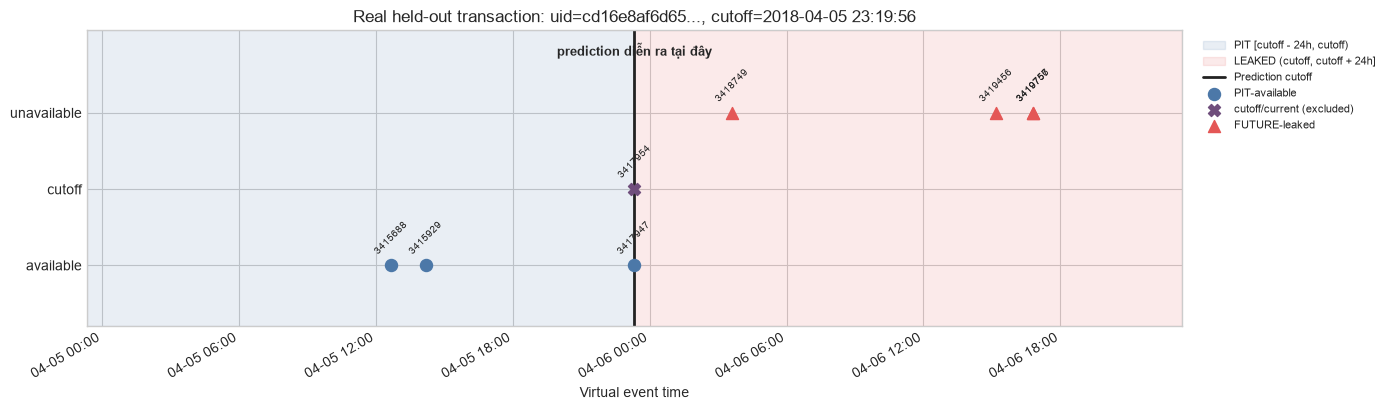

In [11]:
timeline_frame = frames['pit_plus_future']
_, timeline_test_mask = temporal_masks(timeline_frame, split_ts)
timeline_candidates = timeline_frame.loc[
    timeline_test_mask
    & timeline_frame['uid'].notna()
    & timeline_frame['count_txn_24h'].gt(0)
    & timeline_frame['future_count_txn_24h'].gt(0),
    ['label_id', 'uid', 'cutoff_ts', 'label',
     'count_txn_24h', 'future_count_txn_24h'],
].sort_values(['cutoff_ts', 'label_id'])
if timeline_candidates.empty:
    raise RuntimeError('No test transaction has both past and future 24h events.')

timeline_sample = timeline_candidates.iloc[0]
timeline_uid = str(timeline_sample['uid'])
timeline_cutoff = pd.Timestamp(timeline_sample['cutoff_ts'])
timeline_window = pd.Timedelta(hours=24)

connection = duckdb.connect(database_path.as_posix(), read_only=True)
try:
    timeline_events = connection.execute(
        """
        SELECT transaction_id, event_ts, amount, label
        FROM transactions
        WHERE uid = ?
          AND event_ts >= ?
          AND event_ts <= ?
        ORDER BY event_ts, transaction_id
        """,
        [
            timeline_uid,
            (timeline_cutoff - timeline_window).to_pydatetime(),
            (timeline_cutoff + timeline_window).to_pydatetime(),
        ],
    ).df()
finally:
    connection.close()

timeline_events['event_ts'] = pd.to_datetime(timeline_events['event_ts'])
timeline_events['availability'] = np.select(
    [
        timeline_events['event_ts'] < timeline_cutoff,
        timeline_events['event_ts'] == timeline_cutoff,
        timeline_events['event_ts'] > timeline_cutoff,
    ],
    ['PIT-available', 'cutoff/current (excluded)', 'FUTURE-leaked'],
    default='outside window',
)
timeline_events['hours_from_cutoff'] = (
    timeline_events['event_ts'] - timeline_cutoff
).dt.total_seconds() / 3600.0
timeline_past_count = int((timeline_events['event_ts'] < timeline_cutoff).sum())
timeline_cutoff_count = int((timeline_events['event_ts'] == timeline_cutoff).sum())
timeline_future_count = int((timeline_events['event_ts'] > timeline_cutoff).sum())

selected_timeline_events = pd.concat(
    [
        timeline_events[timeline_events['event_ts'] < timeline_cutoff].tail(6),
        timeline_events[timeline_events['event_ts'] == timeline_cutoff].head(3),
        timeline_events[timeline_events['event_ts'] > timeline_cutoff].head(6),
    ],
    ignore_index=True,
).drop_duplicates('transaction_id')

timeline_summary = pd.DataFrame([
    {
        'label_id': int(timeline_sample['label_id']),
        'uid': timeline_uid,
        'cutoff_ts': timeline_cutoff,
        'label': int(timeline_sample['label']),
        'past_events_24h': timeline_past_count,
        'events_at_cutoff_excluded': timeline_cutoff_count,
        'future_events_24h': timeline_future_count,
    }
])
display(timeline_summary)
display(selected_timeline_events[
    ['transaction_id', 'event_ts', 'hours_from_cutoff', 'amount', 'availability']
])

status_style = {
    'PIT-available': (0.25, '#4C78A8', 'o'),
    'cutoff/current (excluded)': (0.50, '#6F4E7C', 'X'),
    'FUTURE-leaked': (0.75, '#E45756', '^'),
}
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.axvspan(
    timeline_cutoff - timeline_window, timeline_cutoff,
    color='#4C78A8', alpha=0.12, label='PIT [cutoff - 24h, cutoff)',
)
ax.axvspan(
    timeline_cutoff, timeline_cutoff + timeline_window,
    color='#E45756', alpha=0.12, label='LEAKED (cutoff, cutoff + 24h]',
)
ax.axvline(
    timeline_cutoff, color='#222222', linewidth=2,
    label='Prediction cutoff',
)
for status, (y_value, color, marker) in status_style.items():
    group = selected_timeline_events[
        selected_timeline_events['availability'] == status
    ]
    ax.scatter(
        group['event_ts'], np.full(len(group), y_value),
        s=75, color=color, marker=marker, zorder=3, label=status,
    )
    for row in group.itertuples(index=False):
        ax.annotate(
            str(row.transaction_id), (row.event_ts, y_value),
            xytext=(0, 8), textcoords='offset points',
            ha='center', fontsize=7, rotation=45,
        )
ax.set_xlim(timeline_cutoff - timeline_window, timeline_cutoff + timeline_window)
ax.set_ylim(0.05, 1.02)
ax.set_yticks([0.25, 0.50, 0.75])
ax.set_yticklabels(['available', 'cutoff', 'unavailable'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.set_xlabel('Virtual event time')
ax.set_title(
    f'Real held-out transaction: uid={timeline_uid[:12]}..., '
    f'cutoff={timeline_cutoff}'
)
ax.text(
    timeline_cutoff, 0.98, 'prediction diễn ra tại đây',
    ha='center', va='top', fontsize=9, fontweight='bold',
)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Existing ROC and Precision-Recall curves

Các curve hiện có được giữ nguyên. Chúng mô tả measured performance, không tự xác định feature có leaked hay không.

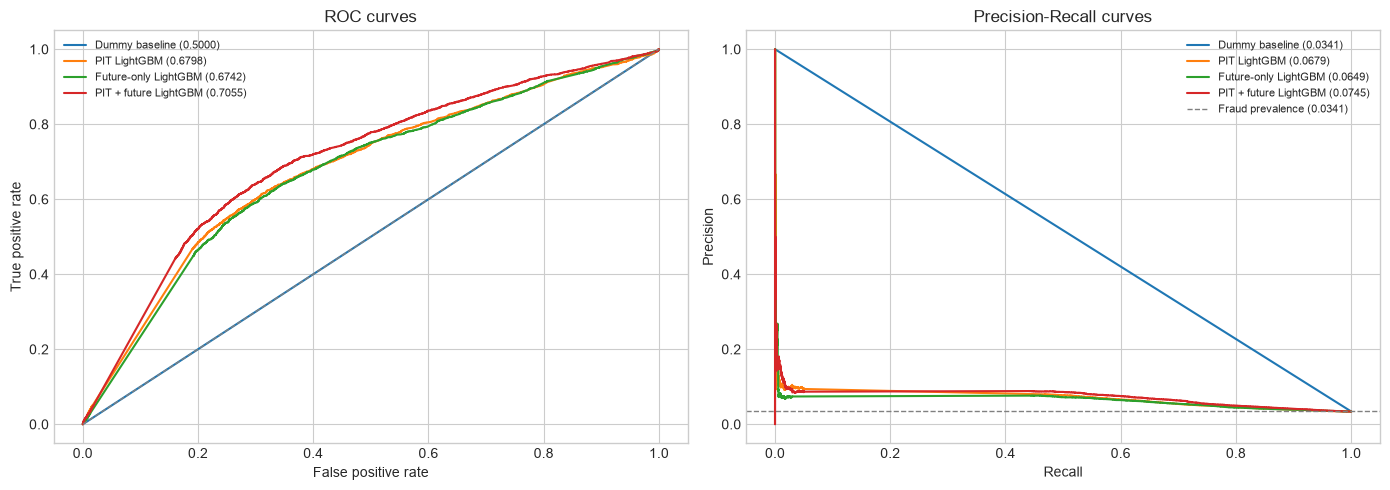

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dataset_name, group in predictions.groupby('dataset', sort=False):
    metric_row = indexed.loc[dataset_name]
    fpr, tpr, _ = roc_curve(group['label'], group['score'])
    precision, recall, _ = precision_recall_curve(group['label'], group['score'])
    axes[0].plot(
        fpr, tpr,
        label=f"{metric_row['model']} ({metric_row['roc_auc']:.4f})",
    )
    axes[1].plot(
        recall, precision,
        label=f"{metric_row['model']} ({metric_row['pr_auc']:.4f})",
    )

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curves')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend(fontsize=8)

prevalence = float(test_labels.mean())
axes[1].axhline(
    prevalence, linestyle='--', color='gray', linewidth=1,
    label=f'Fraud prevalence ({prevalence:.4f})',
)
axes[1].set_title('Precision-Recall curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Existing PIT split importance

Biểu đồ split importance của PIT model được giữ lại như visualization mô tả model gốc. Model-reliance analysis chính cho PIT + Future nằm ở permutation importance trên held-out test set bên dưới.

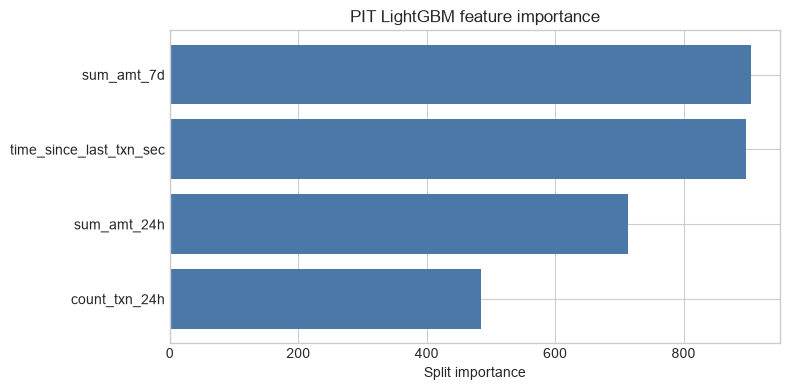

,feature,importance
2,sum_amt_7d,905
3,time_since_last_txn_sec,897
0,sum_amt_24h,714
1,count_txn_24h,484


In [13]:
pit_importance = pd.DataFrame(
    {
        'feature': pit_columns,
        'importance': pit_model.feature_importances_,
    }
).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(pit_importance['feature'], pit_importance['importance'], color='#4C78A8')
ax.set_title('PIT LightGBM feature importance')
ax.set_xlabel('Split importance')
plt.tight_layout()
plt.show()
display(pit_importance.sort_values('importance', ascending=False))

### Visualization 2 — Permutation Importance of PIT + Future

`permutation_importance` chạy trên đúng held-out test rows của `augmented_model` với `scoring='average_precision'`, 10 repeats và seed cố định. Importance dương là mức PR-AUC/average-precision giảm khi alignment của một feature bị phá. Error bar là standard deviation qua permutations, không phải confidence interval. Vì các feature có thể correlated, importance thấp của một feature riêng lẻ không đủ để kết luận model không dùng cả future block.

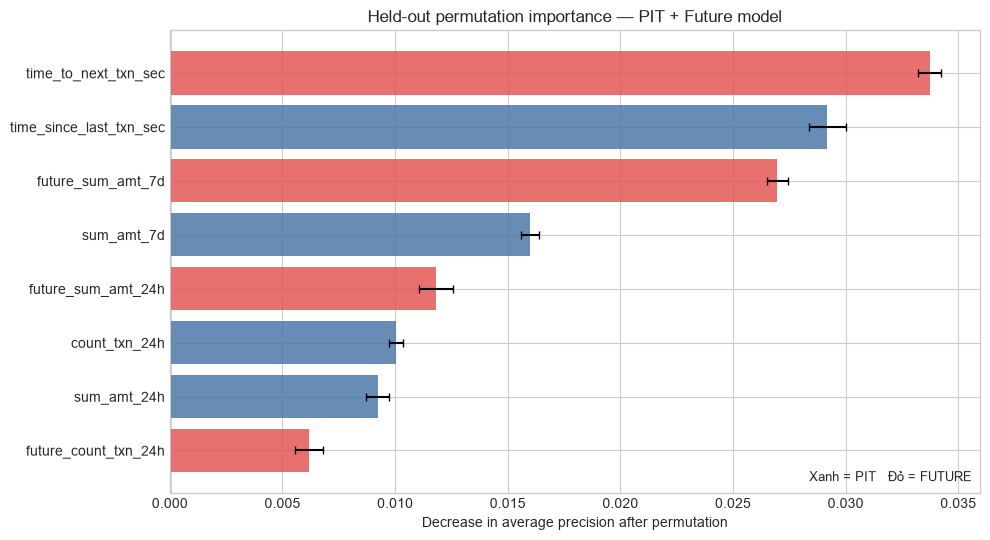

,feature,feature_group,importance_mean,importance_std
0,time_to_next_txn_sec,FUTURE,0.033729,0.000523
1,time_since_last_txn_sec,PIT,0.029188,0.000832
2,future_sum_amt_7d,FUTURE,0.026971,0.000480
3,sum_amt_7d,PIT,0.015976,0.000399
4,future_sum_amt_24h,FUTURE,0.011827,0.000763
5,count_txn_24h,PIT,0.010057,0.000308
6,sum_amt_24h,PIT,0.009225,0.000495
7,future_count_txn_24h,FUTURE,0.006190,0.000628


In [14]:
augmented_frame = frames['pit_plus_future']
_, augmented_test_mask = temporal_masks(augmented_frame, split_ts)
metadata_columns = ['label_id', 'uid', 'cutoff_ts', 'label']
pit_test_spine = pit_frame.loc[test_mask, metadata_columns].reset_index(drop=True)
augmented_test_spine = augmented_frame.loc[
    augmented_test_mask, metadata_columns
].reset_index(drop=True)
if not pit_test_spine.equals(augmented_test_spine):
    raise ValueError('PIT and augmented test rows are not aligned.')

X_test_augmented = augmented_frame.loc[
    augmented_test_mask, augmented_columns
].copy()
y_test_augmented = augmented_frame.loc[
    augmented_test_mask, 'label'
].astype(int)
assert_no_infinite_features(
    X_test_augmented, augmented_columns, 'PIT + Future permutation test'
)
test_target_values, augmented_probability_values = validated_metric_arrays(
    y_test_augmented, augmented_probabilities, 'PIT + Future held-out test'
)
pit_target_values, pit_probability_values = validated_metric_arrays(
    test_labels, pit_probabilities, 'PIT held-out test'
)
if not np.array_equal(test_target_values, pit_target_values):
    raise ValueError('PIT and augmented predictions do not share test labels.')
observed_roc_delta = float(
    roc_auc_score(test_target_values, augmented_probability_values)
    - roc_auc_score(test_target_values, pit_probability_values)
)
observed_pr_delta = float(
    average_precision_score(test_target_values, augmented_probability_values)
    - average_precision_score(test_target_values, pit_probability_values)
)
if not np.isclose(
    observed_roc_delta, controlled_comparison.iloc[0]['roc_auc_delta']
) or not np.isclose(
    observed_pr_delta, controlled_comparison.iloc[0]['pr_auc_delta']
):
    raise ValueError('Aligned predictions do not reproduce controlled deltas.')

permutation_result = permutation_importance(
    augmented_model,
    X_test_augmented,
    test_target_values,
    scoring='average_precision',
    n_repeats=10,
    random_state=random_state,
    n_jobs=1,
)
future_column_set = set(future_columns)
permutation_importance_frame = pd.DataFrame(
    {
        'feature': augmented_columns,
        'feature_group': [
            'FUTURE' if feature in future_column_set else 'PIT'
            for feature in augmented_columns
        ],
        'importance_mean': permutation_result.importances_mean,
        'importance_std': permutation_result.importances_std,
    }
).sort_values('importance_mean')

importance_colors = permutation_importance_frame['feature_group'].map(
    {'PIT': '#4C78A8', 'FUTURE': '#E45756'}
)
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(
    permutation_importance_frame['feature'],
    permutation_importance_frame['importance_mean'],
    xerr=permutation_importance_frame['importance_std'],
    color=importance_colors, alpha=0.85, capsize=3,
)
ax.axvline(0.0, color='#333333', linewidth=1)
ax.set_title('Held-out permutation importance — PIT + Future model')
ax.set_xlabel('Decrease in average precision after permutation')
ax.text(
    0.99, 0.02, 'Xanh = PIT   Đỏ = FUTURE',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
)
plt.tight_layout()
plt.show()
display(permutation_importance_frame.sort_values(
    'importance_mean', ascending=False
).reset_index(drop=True))

top_future_importance = (
    permutation_importance_frame[
        permutation_importance_frame['feature_group'] == 'FUTURE'
    ]
    .sort_values('importance_mean', ascending=False)
    .iloc[0]
)

### Visualization 3 — Future Feature Shuffle Ablation

Đây là post-fit grouped permutation ablation. `augmented_model`, PIT features, labels và test rows được giữ nguyên; không có `.fit()` trong cell experiment. Trong mỗi lần lặp, toàn bộ future block được chuyển bằng cùng một row permutation. Vì vậy internal relationship giữa các future features được giữ lại, nhưng future information không còn thuộc đúng transaction/label. Nếu score gốc PIT + Future nằm cao hơn distribution sau shuffle, model phụ thuộc vào đúng alignment của leaked future information. Shuffled model không bắt buộc rơi đúng về PIT vì model đã được train với future inputs.

,metric,pit_original,pit_plus_future_original,shuffled_mean,shuffled_std,shuffled_p2_5,shuffled_p97_5,original_minus_shuffled_mean,proportion_shuffled_below_original
0,ROC-AUC,0.679783,0.705485,0.581831,0.004504,0.574938,0.590568,0.123655,1.0
1,PR-AUC,0.067894,0.074536,0.043190,0.000695,0.042038,0.044354,0.031346,1.0


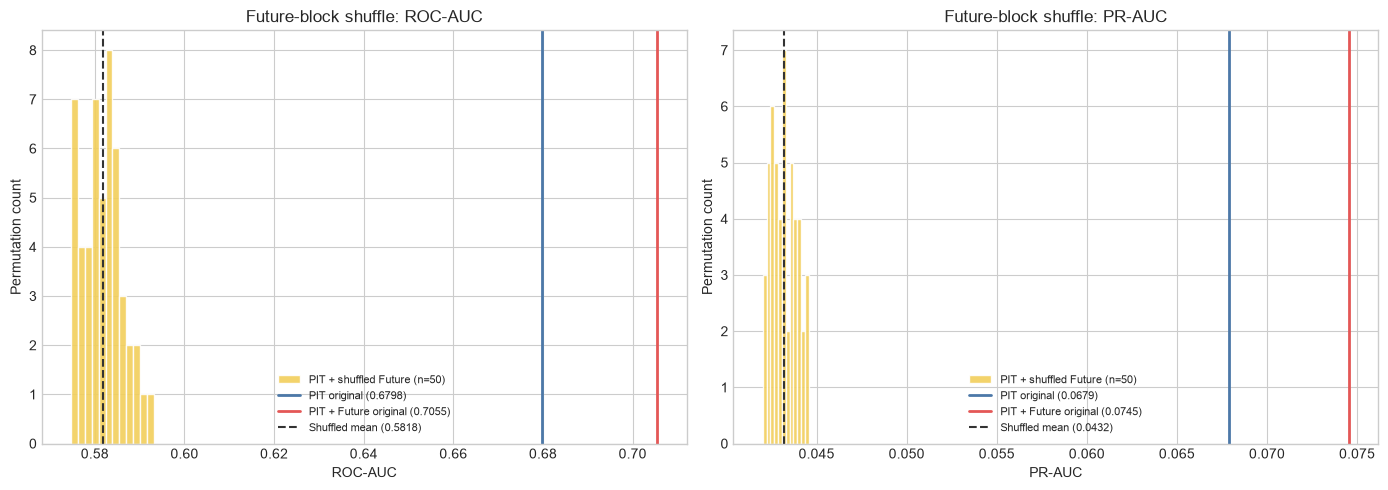

In [15]:
n_future_permutations = 50
shuffle_rng = np.random.default_rng(random_state)
shuffle_records = []

for permutation_id in range(n_future_permutations):
    row_permutation = shuffle_rng.permutation(len(X_test_augmented))
    X_shuffled = X_test_augmented.copy()
    shuffled_future_block = (
        X_test_augmented[future_columns]
        .iloc[row_permutation]
        .set_axis(X_test_augmented.index)
    )
    X_shuffled[future_columns] = shuffled_future_block
    assert_no_infinite_features(
        X_shuffled, augmented_columns,
        f'future block shuffle {permutation_id}',
    )
    shuffled_probabilities = augmented_model.predict_proba(X_shuffled)[:, 1]
    shuffled_targets, shuffled_probability_values = validated_metric_arrays(
        test_target_values, shuffled_probabilities,
        f'future block shuffle {permutation_id}',
    )
    shuffle_records.append(
        {
            'permutation_id': permutation_id,
            'roc_auc': float(roc_auc_score(
                shuffled_targets, shuffled_probability_values
            )),
            'pr_auc': float(average_precision_score(
                shuffled_targets, shuffled_probability_values
            )),
        }
    )

future_shuffle_results = pd.DataFrame(shuffle_records)
if len(future_shuffle_results) != n_future_permutations:
    raise RuntimeError('Future block shuffle did not complete every repeat.')

shuffle_summary_rows = []
for metric, metric_label in [('roc_auc', 'ROC-AUC'), ('pr_auc', 'PR-AUC')]:
    shuffled_values = future_shuffle_results[metric].to_numpy()
    pit_value = float(indexed.loc['pit', metric])
    augmented_value = float(indexed.loc['pit_plus_future', metric])
    shuffle_summary_rows.append(
        {
            'metric': metric_label,
            'pit_original': pit_value,
            'pit_plus_future_original': augmented_value,
            'shuffled_mean': float(shuffled_values.mean()),
            'shuffled_std': float(shuffled_values.std(ddof=1)),
            'shuffled_p2_5': float(np.quantile(shuffled_values, 0.025)),
            'shuffled_p97_5': float(np.quantile(shuffled_values, 0.975)),
            'original_minus_shuffled_mean': float(
                augmented_value - shuffled_values.mean()
            ),
            'proportion_shuffled_below_original': float(
                np.mean(shuffled_values < augmented_value)
            ),
        }
    )
shuffle_summary = pd.DataFrame(shuffle_summary_rows)
display(shuffle_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (metric, metric_label) in zip(
    axes, [('roc_auc', 'ROC-AUC'), ('pr_auc', 'PR-AUC')], strict=True
):
    shuffled_values = future_shuffle_results[metric]
    pit_value = float(indexed.loc['pit', metric])
    augmented_value = float(indexed.loc['pit_plus_future', metric])
    ax.hist(
        shuffled_values, bins=12, color='#F2CF5B',
        edgecolor='white', alpha=0.9,
        label=f'PIT + shuffled Future (n={n_future_permutations})',
    )
    ax.axvline(
        pit_value, color='#4C78A8', linewidth=2,
        label=f'PIT original ({pit_value:.4f})',
    )
    ax.axvline(
        augmented_value, color='#E45756', linewidth=2,
        label=f'PIT + Future original ({augmented_value:.4f})',
    )
    ax.axvline(
        shuffled_values.mean(), color='#333333', linestyle='--',
        linewidth=1.5, label=f'Shuffled mean ({shuffled_values.mean():.4f})',
    )
    ax.set_title(f'Future-block shuffle: {metric_label}')
    ax.set_xlabel(metric_label)
    ax.set_ylabel('Permutation count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Visualization 4 — Paired Bootstrap Confidence Intervals

Mỗi bootstrap replicate sample test rows với replacement và dùng **cùng indices** cho label, PIT score và PIT + Future score. Sample thiếu một trong hai class bị bỏ. Percentile 95% interval và tỷ lệ delta dương mô tả độ ổn định theo test-row resampling; chúng không phải p-value và không bao gồm uncertainty do retraining, model seed, split timestamp hoặc dependence giữa nhiều transaction cùng `uid`.

,metric,point_estimate,bootstrap_mean,ci_lower_95,ci_upper_95,proportion_delta_gt_zero,valid_resamples,requested_resamples
0,ROC-AUC,0.025702,0.025659,0.018583,0.032644,1.0,500,500
1,PR-AUC,0.006641,0.006828,0.004260,0.009443,1.0,500,500


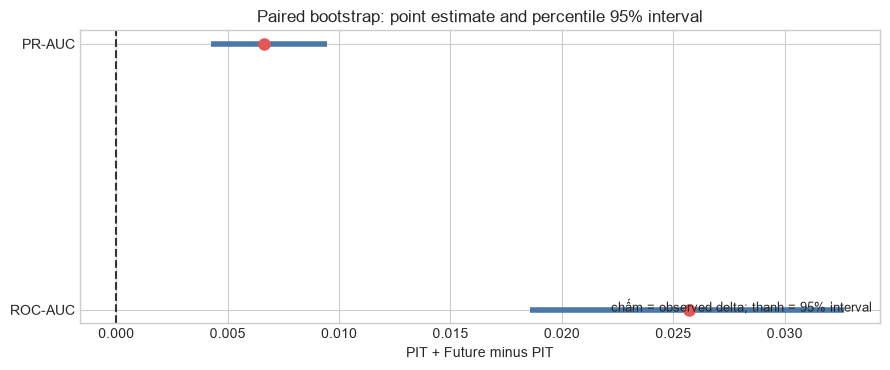

In [16]:
n_bootstrap = 500
bootstrap_rng = np.random.default_rng(random_state)
bootstrap_records = []
n_test_rows = len(test_target_values)

for bootstrap_id in range(n_bootstrap):
    bootstrap_indices = bootstrap_rng.integers(
        0, n_test_rows, size=n_test_rows
    )
    bootstrap_labels = test_target_values[bootstrap_indices]
    if np.unique(bootstrap_labels).size < 2:
        continue
    bootstrap_pit_scores = pit_probability_values[bootstrap_indices]
    bootstrap_augmented_scores = augmented_probability_values[
        bootstrap_indices
    ]
    bootstrap_records.append(
        {
            'bootstrap_id': bootstrap_id,
            'delta_roc_auc': float(
                roc_auc_score(bootstrap_labels, bootstrap_augmented_scores)
                - roc_auc_score(bootstrap_labels, bootstrap_pit_scores)
            ),
            'delta_pr_auc': float(
                average_precision_score(
                    bootstrap_labels, bootstrap_augmented_scores
                )
                - average_precision_score(
                    bootstrap_labels, bootstrap_pit_scores
                )
            ),
        }
    )

bootstrap_deltas = pd.DataFrame(bootstrap_records)
if len(bootstrap_deltas) < int(0.95 * n_bootstrap):
    raise RuntimeError('Too many paired bootstrap samples lacked both classes.')

bootstrap_summary_rows = []
bootstrap_metric_config = [
    ('ROC-AUC', 'delta_roc_auc', float(controlled_comparison.iloc[0]['roc_auc_delta'])),
    ('PR-AUC', 'delta_pr_auc', float(controlled_comparison.iloc[0]['pr_auc_delta'])),
]
for metric_label, delta_column, point_estimate in bootstrap_metric_config:
    delta_values = bootstrap_deltas[delta_column].to_numpy()
    bootstrap_summary_rows.append(
        {
            'metric': metric_label,
            'point_estimate': point_estimate,
            'bootstrap_mean': float(delta_values.mean()),
            'ci_lower_95': float(np.quantile(delta_values, 0.025)),
            'ci_upper_95': float(np.quantile(delta_values, 0.975)),
            'proportion_delta_gt_zero': float(np.mean(delta_values > 0)),
            'valid_resamples': len(delta_values),
            'requested_resamples': n_bootstrap,
        }
    )
bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
display(bootstrap_summary)

fig, ax = plt.subplots(figsize=(9, 3.8))
for y_position, row in enumerate(bootstrap_summary.itertuples(index=False)):
    ax.hlines(
        y_position, row.ci_lower_95, row.ci_upper_95,
        color='#4C78A8', linewidth=4,
    )
    ax.plot(
        row.point_estimate, y_position, 'o', color='#E45756', markersize=8
    )
ax.axvline(0.0, color='#333333', linestyle='--', linewidth=1.5)
ax.set_yticks(range(len(bootstrap_summary)))
ax.set_yticklabels(bootstrap_summary['metric'])
ax.set_xlabel('PIT + Future minus PIT')
ax.set_title('Paired bootstrap: point estimate and percentile 95% interval')
ax.text(
    0.99, 0.03, 'chấm = observed delta; thanh = 95% interval',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
)
plt.tight_layout()
plt.show()

## 11. Leakage Evidence Summary

Bảng dưới lấy toàn bộ số liệu từ variables vừa tính. Temporal availability xác định **existence**; các hàng còn lại đo **impact**, **model reliance** và **uncertainty**.

In [17]:
shuffle_by_metric = shuffle_summary.set_index('metric')
bootstrap_by_metric = bootstrap_summary.set_index('metric')
evidence_summary = pd.DataFrame(
    [
        {
            'Evidence': 'Temporal boundary',
            'What it tests': 'Future feature có available tại cutoff không?',
            'Result': (
                'Không: future contract là (cutoff, cutoff + window], nên '
                'feature_ts > cutoff_ts. Sample có '
                f'{timeline_future_count} event sau cutoff; '
                f'{timeline_cutoff_count} event tại cutoff cũng bị loại.'
            ),
        },
        {
            'Evidence': 'PIT vs PIT + Future',
            'What it tests': 'Thêm future information có đổi performance không?',
            'Result': (
                f"ROC-AUC {controlled_comparison.iloc[0]['roc_auc_delta']:+.6f}; "
                f"PR-AUC {controlled_comparison.iloc[0]['pr_auc_delta']:+.6f}."
            ),
        },
        {
            'Evidence': 'Permutation importance',
            'What it tests': 'Fitted model có phụ thuộc future feature không?',
            'Result': (
                f"Future feature cao nhất: {top_future_importance['feature']} = "
                f"{top_future_importance['importance_mean']:+.6f} "
                f"± {top_future_importance['importance_std']:.6f} AP."
            ),
        },
        {
            'Evidence': 'Future shuffle ablation',
            'What it tests': 'Đúng future-row alignment có tạo ra gain không?',
            'Result': (
                f"Original trừ shuffled mean: ROC-AUC "
                f"{shuffle_by_metric.loc['ROC-AUC', 'original_minus_shuffled_mean']:+.6f}; "
                f"PR-AUC {shuffle_by_metric.loc['PR-AUC', 'original_minus_shuffled_mean']:+.6f}."
            ),
        },
        {
            'Evidence': 'Paired bootstrap CI',
            'What it tests': 'Measured delta có ổn định khi resample test rows không?',
            'Result': (
                f"ROC 95% CI [{bootstrap_by_metric.loc['ROC-AUC', 'ci_lower_95']:+.6f}, "
                f"{bootstrap_by_metric.loc['ROC-AUC', 'ci_upper_95']:+.6f}]; "
                f"PR 95% CI [{bootstrap_by_metric.loc['PR-AUC', 'ci_lower_95']:+.6f}, "
                f"{bootstrap_by_metric.loc['PR-AUC', 'ci_upper_95']:+.6f}]."
            ),
        },
    ]
)
display(evidence_summary)

,Evidence,What it tests,Result
0,Temporal boundary,Future feature có available tại cutoff không?,"Không: future contract là (cutoff, cutoff + wi..."
1,PIT vs PIT + Future,Thêm future information có đổi performance không?,ROC-AUC +0.025702; PR-AUC +0.006641.
2,Permutation importance,Fitted model có phụ thuộc future feature không?,Future feature cao nhất: time_to_next_txn_sec ...
3,Future shuffle ablation,Đúng future-row alignment có tạo ra gain không?,Original trừ shuffled mean: ROC-AUC +0.123655;...
4,Paired bootstrap CI,Measured delta có ổn định khi resample test ro...,"ROC 95% CI [+0.018583, +0.032644]; PR 95% CI [..."


## 12. Conclusion

Conclusion bên dưới được render từ kết quả runtime để tách riêng point-in-time correctness, định nghĩa leakage, model reliance và measured performance impact. Không có metric nào được hard-code.

In [18]:
top_future_mean = float(top_future_importance['importance_mean'])
top_future_std = float(top_future_importance['importance_std'])
shuffle_roc_drop = float(
    shuffle_by_metric.loc['ROC-AUC', 'original_minus_shuffled_mean']
)
shuffle_pr_drop = float(
    shuffle_by_metric.loc['PR-AUC', 'original_minus_shuffled_mean']
)

if top_future_mean - 2 * top_future_std > 0:
    individual_reliance_text = (
        f"Future feature dẫn đầu, `{top_future_importance['feature']}`, "
        f"có mức held-out AP decrease dương {top_future_mean:.6f} "
        f"± {top_future_std:.6f} qua các permutations."
    )
else:
    individual_reliance_text = (
        "Không có future feature riêng lẻ nào vượt ngưỡng bảo thủ "
        f"mean - 2×std > 0; mean lớn nhất là {top_future_mean:.6f}. "
        "Điều này không chứng minh model không sử dụng future features, "
        "vì các feature correlated có thể thay thế tín hiệu của nhau."
    )

shuffle_roc_support = float(
    shuffle_by_metric.loc['ROC-AUC', 'proportion_shuffled_below_original']
)
shuffle_pr_support = float(
    shuffle_by_metric.loc['PR-AUC', 'proportion_shuffled_below_original']
)
if (
    shuffle_roc_drop > 0
    and shuffle_pr_drop > 0
    and shuffle_roc_support >= 0.95
    and shuffle_pr_support >= 0.95
):
    block_reliance_text = (
        f"Shuffle future block làm mean ROC-AUC giảm "
        f"{shuffle_roc_drop:.6f} và mean PR-AUC giảm {shuffle_pr_drop:.6f}; "
        f"{shuffle_roc_support:.1%}/{shuffle_pr_support:.1%} shuffled "
        "ROC/PR scores thấp hơn original. Kết quả này hỗ trợ kết luận model "
        "phụ thuộc vào future information được align đúng."
    )
else:
    block_reliance_text = (
        f"Grouped shuffle làm ROC-AUC thay đổi {shuffle_roc_drop:+.6f} "
        f"và PR-AUC thay đổi {shuffle_pr_drop:+.6f} so với original. "
        "Run này chưa cho thấy reliance signal dương nhất quán trên cả hai metrics."
    )

def bootstrap_interpretation(metric):
    row = bootstrap_by_metric.loc[metric]
    interval = f"[{row['ci_lower_95']:+.6f}, {row['ci_upper_95']:+.6f}]"
    if row['ci_lower_95'] > 0:
        interpretation = 'nằm hoàn toàn trên 0 và hỗ trợ measured inflation dương'
    elif row['ci_upper_95'] < 0:
        interpretation = 'nằm hoàn toàn dưới 0 trong run này'
    else:
        interpretation = (
            'đi qua 0 nên độ lớn hoặc hướng của metric inflation chưa ổn định; '
            'temporal leakage vẫn tồn tại'
        )
    return (
        f"{metric} delta {row['point_estimate']:+.6f}, 95% CI {interval}, "
        f"tỷ lệ bootstrap delta > 0 = {row['proportion_delta_gt_zero']:.3f}; "
        f"interval {interpretation}."
    )

conclusion_markdown = f"""
### Point-in-time correctness

PIT dataset chỉ dùng event trong `[cutoff - window, cutoff)`: bao gồm lower boundary, đồng thời loại transaction hiện tại và mọi event về sau. Các dataset vẫn dùng cùng label spine và temporal split.

### Leakage definition

Future features dùng `(cutoff, cutoff + window]`, nên các giá trị có `feature_ts > cutoff_ts` chưa tồn tại khi model phải prediction. **Temporal availability xác lập leakage; metric không cần tăng để gọi đây là leakage.**

### Model reliance

{individual_reliance_text} {block_reliance_text}

### Performance impact

Controlled comparison giữ PIT information trong cả hai model và chỉ thay đổi quyền truy cập future block. {bootstrap_interpretation('ROC-AUC')} {bootstrap_interpretation('PR-AUC')} Các row-bootstrap intervals này có điều kiện trên fixed models và fixed split; chúng không phải kết luận cho mọi lần retrain hoặc mọi giai đoạn thời gian.

Future-only vẫn là diagnostic phụ: model này thay historical signal bằng future signal thay vì cô lập tác động của việc thêm future information, nên không bắt buộc phải outperform PIT.
"""
display(Markdown(conclusion_markdown))


### Point-in-time correctness

PIT dataset chỉ dùng event trong `[cutoff - window, cutoff)`: bao gồm lower boundary, đồng thời loại transaction hiện tại và mọi event về sau. Các dataset vẫn dùng cùng label spine và temporal split.

### Leakage definition

Future features dùng `(cutoff, cutoff + window]`, nên các giá trị có `feature_ts > cutoff_ts` chưa tồn tại khi model phải prediction. **Temporal availability xác lập leakage; metric không cần tăng để gọi đây là leakage.**

### Model reliance

Future feature dẫn đầu, `time_to_next_txn_sec`, có mức held-out AP decrease dương 0.033729 ± 0.000523 qua các permutations. Shuffle future block làm mean ROC-AUC giảm 0.123655 và mean PR-AUC giảm 0.031346; 100.0%/100.0% shuffled ROC/PR scores thấp hơn original. Kết quả này hỗ trợ kết luận model phụ thuộc vào future information được align đúng.

### Performance impact

Controlled comparison giữ PIT information trong cả hai model và chỉ thay đổi quyền truy cập future block. ROC-AUC delta +0.025702, 95% CI [+0.018583, +0.032644], tỷ lệ bootstrap delta > 0 = 1.000; interval nằm hoàn toàn trên 0 và hỗ trợ measured inflation dương. PR-AUC delta +0.006641, 95% CI [+0.004260, +0.009443], tỷ lệ bootstrap delta > 0 = 1.000; interval nằm hoàn toàn trên 0 và hỗ trợ measured inflation dương. Các row-bootstrap intervals này có điều kiện trên fixed models và fixed split; chúng không phải kết luận cho mọi lần retrain hoặc mọi giai đoạn thời gian.

Future-only vẫn là diagnostic phụ: model này thay historical signal bằng future signal thay vì cô lập tác động của việc thêm future information, nên không bắt buộc phải outperform PIT.


### Export reproducible results

Metrics được ghi trực tiếp từ các giá trị vừa tính; không hard-code kết quả.

In [19]:
report_dir.mkdir(parents=True, exist_ok=True)
if not np.isfinite(metrics[['roc_auc', 'pr_auc']].to_numpy()).all():
    raise ValueError('Model metrics contain NaN or infinity before export.')
metrics.to_csv(metrics_path, index=False, float_format='%.10f')

comparison_rows = '\n'.join(
    f"| {row.model} | {row.feature_count} | {row.roc_auc:.6f} | {row.pr_auc:.6f} |"
    for row in model_comparison.itertuples(index=False)
)
bootstrap_report_rows = '\n'.join(
    f"| {row.metric} | {row.point_estimate:+.6f} | {row.bootstrap_mean:+.6f} | "
    f"[{row.ci_lower_95:+.6f}, {row.ci_upper_95:+.6f}] | "
    f"{row.proportion_delta_gt_zero:.3f} | {row.valid_resamples} |"
    for row in bootstrap_summary.itertuples(index=False)
)
shuffle_report_rows = '\n'.join(
    f"| {row.metric} | {row.pit_original:.6f} | "
    f"{row.pit_plus_future_original:.6f} | {row.shuffled_mean:.6f} | "
    f"{row.shuffled_std:.6f} | {row.original_minus_shuffled_mean:+.6f} | "
    f"{row.proportion_shuffled_below_original:.3f} |"
    for row in shuffle_summary.itertuples(index=False)
)
controlled_row = controlled_comparison.iloc[0]
report_markdown = f"""# Leakage experiment

- Eligible cohort: `{bounds.start}` đến `{bounds.end}`
- Temporal split: train `< {split_ts}`, test `>= {split_ts}`
- PIT semantics: `[cutoff - window, cutoff)`
- Future semantics: `(cutoff, cutoff + window]`

## Model metrics

| Model | Feature count | ROC-AUC | PR-AUC |
|---|---:|---:|---:|
{comparison_rows}

## Leakage existence

Future features yêu cầu `feature_ts > cutoff_ts`, nên chúng chưa available khi prediction diễn ra. Temporal violation này xác lập leakage độc lập với model metrics. Timeline sample thật có `{timeline_future_count}` event sau cutoff trong future window 24 giờ.

## Controlled metric delta

PIT + Future trừ PIT: ROC-AUC `{controlled_row['roc_auc_delta']:+.6f}`, PR-AUC `{controlled_row['pr_auc_delta']:+.6f}`.

## Paired bootstrap uncertainty

| Metric | Point delta | Bootstrap mean | Percentile 95% CI | Proportion delta > 0 | Valid resamples |
|---|---:|---:|---:|---:|---:|
{bootstrap_report_rows}

Các interval resample cùng test rows cho cả hai fixed models. Chúng không bao gồm uncertainty do retraining, lựa chọn split hoặc entity cluster.

## Future-block shuffle ablation

| Metric | PIT original | PIT + Future original | Shuffled mean | Shuffled std | Original - shuffled mean | Proportion shuffled below original |
|---|---:|---:|---:|---:|---:|---:|
{shuffle_report_rows}

Fitted augmented model được giữ nguyên. Mỗi repeat chuyển toàn bộ future columns bằng cùng một row permutation, nhờ đó giữ relationship bên trong block nhưng phá alignment với transaction và label tương ứng.

## Top future permutation importance

`{top_future_importance['feature']}`: mean held-out average-precision decrease `{top_future_importance['importance_mean']:+.6f}`, với permutation standard deviation `{top_future_importance['importance_std']:.6f}`.

Future-only là leakage diagnostic có chủ đích, không phải model hợp lệ cho production. Temporal availability xác lập leakage; các controlled comparisons phía trên đo observed impact và model reliance.
"""
markdown_path.write_text(report_markdown, encoding='utf-8')

exported_metrics = pd.read_csv(metrics_path)
assert len(exported_metrics) == 4
assert set(exported_metrics['dataset']) == {
    'dummy_baseline', 'pit', 'future_only', 'pit_plus_future'
}
exported_report = markdown_path.read_text(encoding='utf-8')
for required_heading in [
    '## Controlled metric delta',
    '## Paired bootstrap uncertainty',
    '## Future-block shuffle ablation',
    '## Top future permutation importance',
]:
    assert required_heading in exported_report
print(f'Đã ghi metrics: {metrics_path}')
print(f'Đã ghi report: {markdown_path}')

Đã ghi metrics: C:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_metrics.csv
Đã ghi report: C:\Users\tiennd49\Documents\point-in-time-feature-store\artifacts\reports\leakage_experiment.md


## 13. Research Sources

- Kaufman, Rosset, Perlich & Stitelman — [*Leakage in Data Mining: Formulation, Detection, and Avoidance*](https://doi.org/10.1145/2382577.2382579).
- Feast — [*Point-in-time joins*](https://docs.feast.dev/getting-started/concepts/point-in-time-joins).
- scikit-learn — [*Permutation feature importance*](https://scikit-learn.org/stable/modules/permutation_importance.html).
- Fisher, Rudin & Dominici (2019) — [*All Models are Wrong, but Many are Useful*](https://www.jmlr.org/papers/v20/18-760.html), cơ sở cho model/variable reliance bằng permutation.
- Kapoor & Narayanan (2023) — [*Leakage and the Reproducibility Crisis in Machine-Learning-Based Science*](https://doi.org/10.1016/j.patter.2023.100804).
- Efron (1979) — [*Bootstrap Methods: Another Look at the Jackknife*](https://doi.org/10.1214/aos/1176344552).
- Zhang & Tang (2020) — [confidence intervals for differences between correlated ROC AUCs](https://doi.org/10.1002/sim.8562).
- Boyd, Eng & Page (2013) — [*Area under the Precision-Recall Curve: Point Estimates and Confidence Intervals*](https://doi.org/10.1007/978-3-642-40994-3_29).